<a href="https://colab.research.google.com/github/EnassAli/Data-Quality-Assessment-Preprocessing-on-IoT-dataset-for-Intrusion-Detection-Systems/blob/main/Lab_4_Data_Quality_IoT_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This notebook focuses on data quality assessment and preprocessing on IoT dataset for Intrusion Detection Systems.

# It includes checking the dataset structure, handling missing values,
# removing duplicate rows, encoding categorical data, detecting outliers,
# and creating visualizations to better understand the dataset.

# 1) Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2) Load dataset


In [3]:
df = pd.read_csv("BoTNeTIoT-L01-v2.csv")

# 3) Display first rows

In [4]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   MI_dir_L0.1_weight  MI_dir_L0.1_mean  MI_dir_L0.1_variance  H_L0.1_weight  \
0            1.000000         98.000000          0.000000e+00       1.000000   
1            1.931640         98.000000          1.818989e-12       1.931640   
2            2.904273         86.981750          2.311822e+02       2.904273   
3            3.902546         83.655268          2.040614e+02       3.902546   
4            4.902545         81.685828          1.775746e+02       4.902545   

   H_L0.1_mean  H_L0.1_variance  HH_L0.1_weight  HH_L0.1_mean   HH_L0.1_std  \
0    98.000000     0.000000e+00         1.00000          98.0  0.000000e+00   
1    98.000000     1.818989e-12         1.93164          98.0  1.348699e-06   
2    86.981750     2.311822e+02         1.00000          66.0  0.000000e+00   
3    83.655268     2.040614e+02         1.00000          74.0  0.000000e+00   
4    81.685828     1.775746e+02         2.00000          74.0  9.536743e-07   

   HH_L0.1_magnitude  ...  HpH

# 4) Check data structure

In [5]:
print("\nDataset Info:")
print(df.info())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7062606 entries, 0 to 7062605
Data columns (total 27 columns):
 #   Column                Dtype  
---  ------                -----  
 0   MI_dir_L0.1_weight    float64
 1   MI_dir_L0.1_mean      float64
 2   MI_dir_L0.1_variance  float64
 3   H_L0.1_weight         float64
 4   H_L0.1_mean           float64
 5   H_L0.1_variance       float64
 6   HH_L0.1_weight        float64
 7   HH_L0.1_mean          float64
 8   HH_L0.1_std           float64
 9   HH_L0.1_magnitude     float64
 10  HH_L0.1_radius        float64
 11  HH_L0.1_covariance    float64
 12  HH_L0.1_pcc           float64
 13  HH_jit_L0.1_weight    float64
 14  HH_jit_L0.1_mean      float64
 15  HH_jit_L0.1_variance  float64
 16  HpHp_L0.1_weight      float64
 17  HpHp_L0.1_mean        float64
 18  HpHp_L0.1_std         float64
 19  HpHp_L0.1_magnitude   float64
 20  HpHp_L0.1_radius      float64
 21  HpHp_L0.1_covariance  float64
 22  HpHp_L0.1_pcc         float

# 5) Summary statistics


In [6]:
print("\nDescriptive statistics:")
print(df.describe(include='all'))


Descriptive statistics:
        MI_dir_L0.1_weight  MI_dir_L0.1_mean  MI_dir_L0.1_variance  \
count         7.062606e+06      7.062606e+06          7.062606e+06   
unique                 NaN               NaN                   NaN   
top                    NaN               NaN                   NaN   
freq                   NaN               NaN                   NaN   
mean          3.400682e+03      1.794441e+02          1.931062e+04   
std           2.897012e+03      1.537109e+02          2.636844e+04   
min           1.000000e+00      6.000000e+01          0.000000e+00   
25%           1.000000e+00      6.000000e+01          0.000000e+00   
50%           3.644882e+03      7.412707e+01          9.807711e+01   
75%           6.354692e+03      3.486463e+02          4.887076e+04   
max           8.946997e+03      1.401994e+03          4.520011e+05   

        H_L0.1_weight   H_L0.1_mean  H_L0.1_variance  HH_L0.1_weight  \
count    7.062606e+06  7.062606e+06     7.062606e+06    7.0626

# 6) Check missing values


In [7]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
MI_dir_L0.1_weight      0
MI_dir_L0.1_mean        0
MI_dir_L0.1_variance    0
H_L0.1_weight           0
H_L0.1_mean             0
H_L0.1_variance         0
HH_L0.1_weight          0
HH_L0.1_mean            0
HH_L0.1_std             0
HH_L0.1_magnitude       0
HH_L0.1_radius          0
HH_L0.1_covariance      0
HH_L0.1_pcc             0
HH_jit_L0.1_weight      0
HH_jit_L0.1_mean        0
HH_jit_L0.1_variance    0
HpHp_L0.1_weight        0
HpHp_L0.1_mean          0
HpHp_L0.1_std           0
HpHp_L0.1_magnitude     0
HpHp_L0.1_radius        0
HpHp_L0.1_covariance    0
HpHp_L0.1_pcc           0
Device_Name             0
Attack                  0
Attack_subType          0
label                   0
dtype: int64


# 7) Fill missing values

In [8]:
# For Numrical colunms
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# For Text colunms
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
MI_dir_L0.1_weight      0
MI_dir_L0.1_mean        0
MI_dir_L0.1_variance    0
H_L0.1_weight           0
H_L0.1_mean             0
H_L0.1_variance         0
HH_L0.1_weight          0
HH_L0.1_mean            0
HH_L0.1_std             0
HH_L0.1_magnitude       0
HH_L0.1_radius          0
HH_L0.1_covariance      0
HH_L0.1_pcc             0
HH_jit_L0.1_weight      0
HH_jit_L0.1_mean        0
HH_jit_L0.1_variance    0
HpHp_L0.1_weight        0
HpHp_L0.1_mean          0
HpHp_L0.1_std           0
HpHp_L0.1_magnitude     0
HpHp_L0.1_radius        0
HpHp_L0.1_covariance    0
HpHp_L0.1_pcc           0
Device_Name             0
Attack                  0
Attack_subType          0
label                   0
dtype: int64


Missing values in numerical columns were filled using the median because it is robust to outliers, while categorical values were filled using the mode as it represents the most frequent category.

**Missing values were handled using the median for numerical features because it is less affected by outliers, while the mode was used for categorical features as it represents the most frequent value.**

# 8) Check duplicates

In [9]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


Number of duplicate rows:
621659

Shape after removing duplicates:
(6440947, 27)


# 9) Check data types

In [10]:
print("\nData types:")
print(df.dtypes)


Data types:
MI_dir_L0.1_weight      float64
MI_dir_L0.1_mean        float64
MI_dir_L0.1_variance    float64
H_L0.1_weight           float64
H_L0.1_mean             float64
H_L0.1_variance         float64
HH_L0.1_weight          float64
HH_L0.1_mean            float64
HH_L0.1_std             float64
HH_L0.1_magnitude       float64
HH_L0.1_radius          float64
HH_L0.1_covariance      float64
HH_L0.1_pcc             float64
HH_jit_L0.1_weight      float64
HH_jit_L0.1_mean        float64
HH_jit_L0.1_variance    float64
HpHp_L0.1_weight        float64
HpHp_L0.1_mean          float64
HpHp_L0.1_std           float64
HpHp_L0.1_magnitude     float64
HpHp_L0.1_radius        float64
HpHp_L0.1_covariance    float64
HpHp_L0.1_pcc           float64
Device_Name              object
Attack                   object
Attack_subType           object
label                     int64
dtype: object


# 10) Convert categorical columns into numeric if needed


In [11]:
df = pd.get_dummies(df, drop_first=True)

print("\nDataset after encoding:")
print(df.head())


Dataset after encoding:
   MI_dir_L0.1_weight  MI_dir_L0.1_mean  MI_dir_L0.1_variance  H_L0.1_weight  \
0            1.000000         98.000000          0.000000e+00       1.000000   
1            1.931640         98.000000          1.818989e-12       1.931640   
2            2.904273         86.981750          2.311822e+02       2.904273   
3            3.902546         83.655268          2.040614e+02       3.902546   
4            4.902545         81.685828          1.775746e+02       4.902545   

   H_L0.1_mean  H_L0.1_variance  HH_L0.1_weight  HH_L0.1_mean   HH_L0.1_std  \
0    98.000000     0.000000e+00         1.00000          98.0  0.000000e+00   
1    98.000000     1.818989e-12         1.93164          98.0  1.348699e-06   
2    86.981750     2.311822e+02         1.00000          66.0  0.000000e+00   
3    83.655268     2.040614e+02         1.00000          74.0  0.000000e+00   
4    81.685828     1.775746e+02         2.00000          74.0  9.536743e-07   

   HH_L0.1_magnitud

# 11) Detect outliers using IQR method


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutliers in {col}: {len(outliers)}")

    # Remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]



Outliers in MI_dir_L0.1_weight: 0

Outliers in MI_dir_L0.1_mean: 818

Outliers in MI_dir_L0.1_variance: 3188

Outliers in H_L0.1_weight: 0

Outliers in H_L0.1_mean: 818

Outliers in H_L0.1_variance: 3188

Outliers in HH_L0.1_weight: 0

Outliers in HH_L0.1_mean: 2062

Outliers in HH_L0.1_std: 470743

Outliers in HH_L0.1_magnitude: 3475

Outliers in HH_L0.1_radius: 1113702

Outliers in HH_L0.1_covariance: 1236109

Outliers in HH_L0.1_pcc: 1160020

Outliers in HH_jit_L0.1_weight: 0

Outliers in HH_jit_L0.1_mean: 0

Outliers in HH_jit_L0.1_variance: 1457713

Outliers in HpHp_L0.1_weight: 1285430

Outliers in HpHp_L0.1_mean: 2436

Outliers in HpHp_L0.1_std: 970600

Outliers in HpHp_L0.1_magnitude: 3865

Outliers in HpHp_L0.1_radius: 1020044

Outliers in HpHp_L0.1_covariance: 404435

Outliers in HpHp_L0.1_pcc: 295601

Outliers in label: 513500


Outliers were removed using the IQR method to reduce noise and improve data quality.

## 12) Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = scaler.fit_transform(df[numeric_cols])

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = scaler.fit_transform(df[numeric_cols])

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)


In [15]:
corr = df[numeric_cols].corr()
print(corr)

                      MI_dir_L0.1_weight  MI_dir_L0.1_mean  \
MI_dir_L0.1_weight              1.000000          0.759753   
MI_dir_L0.1_mean                0.759753          1.000000   
MI_dir_L0.1_variance            0.701690          0.965056   
H_L0.1_weight                   1.000000          0.759753   
H_L0.1_mean                     0.759753          1.000000   
H_L0.1_variance                 0.701690          0.965056   
HH_L0.1_weight                       NaN               NaN   
HH_L0.1_mean                         NaN               NaN   
HH_L0.1_std                          NaN               NaN   
HH_L0.1_magnitude                    NaN               NaN   
HH_L0.1_radius                       NaN               NaN   
HH_L0.1_covariance                   NaN               NaN   
HH_L0.1_pcc                          NaN               NaN   
HH_jit_L0.1_weight                   NaN               NaN   
HH_jit_L0.1_mean                0.828391          0.569095   
HH_jit_L

## Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[numeric_cols])

print(pca.explained_variance_ratio_)

[0.99883114 0.00116484]


PCA was applied because some numerical features showed correlation, helping reduce dimensionality.

# 13) Simple visualizations

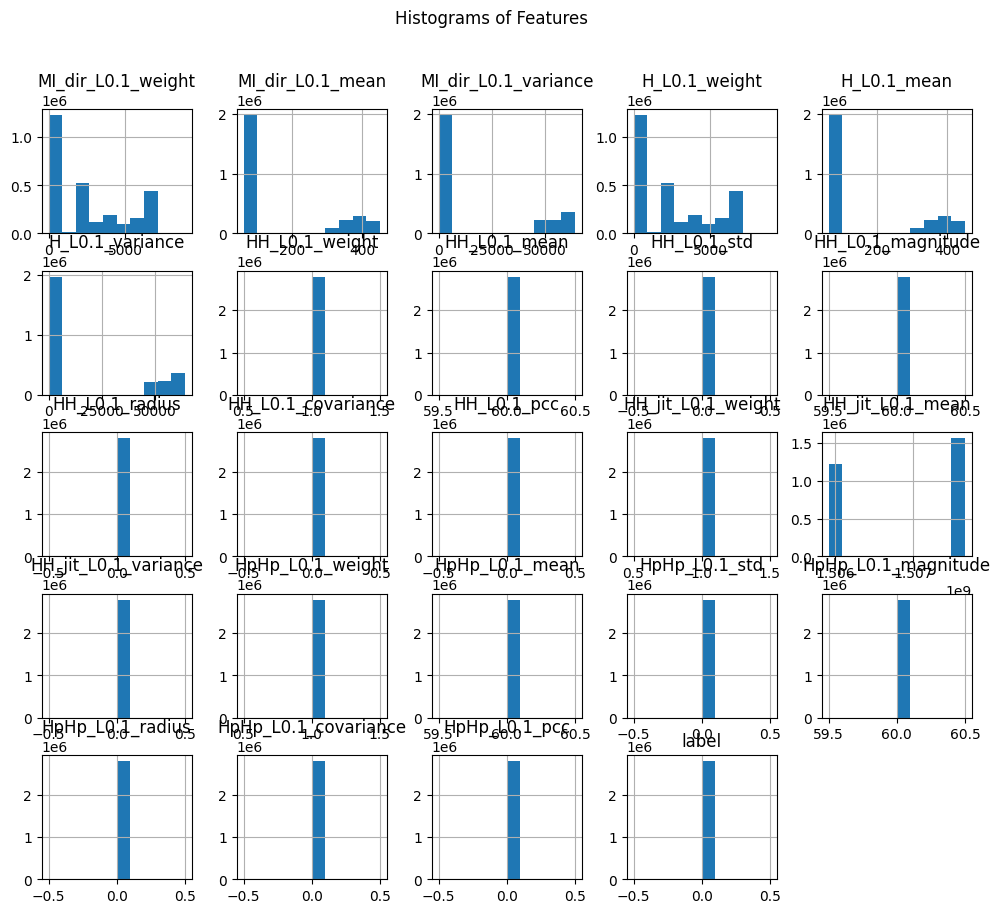

In [17]:
# Histograms
df.hist(figsize=(12, 10))
plt.suptitle("Histograms of Features")
plt.show()


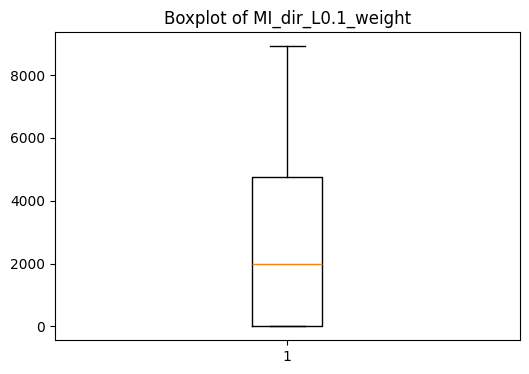

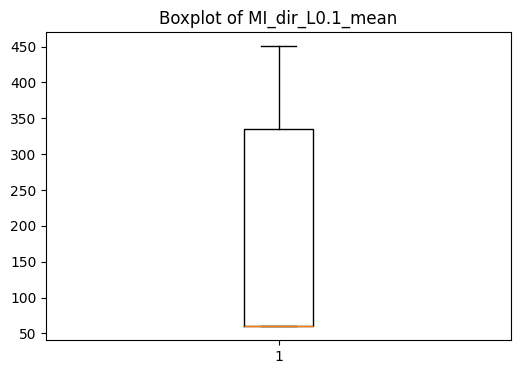

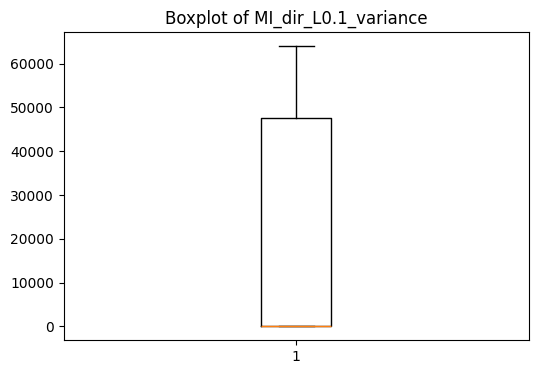

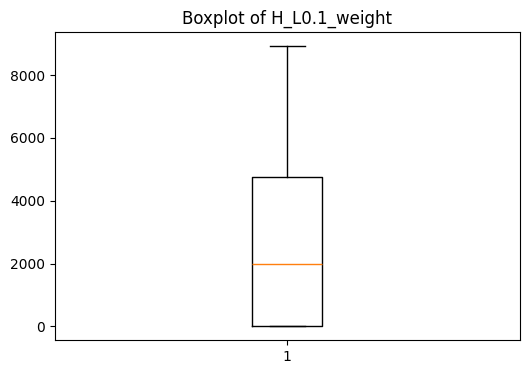

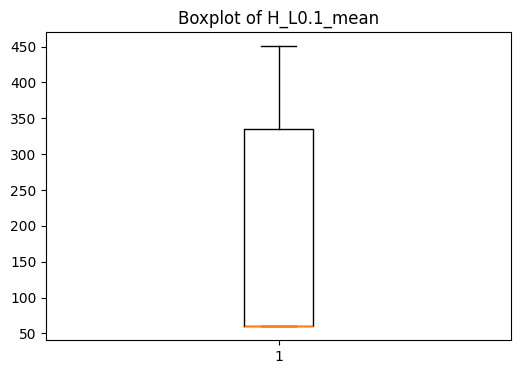

In [18]:
# Boxplot for numeric columns
for col in numeric_cols[:5]:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

# 14) Correlation matrix


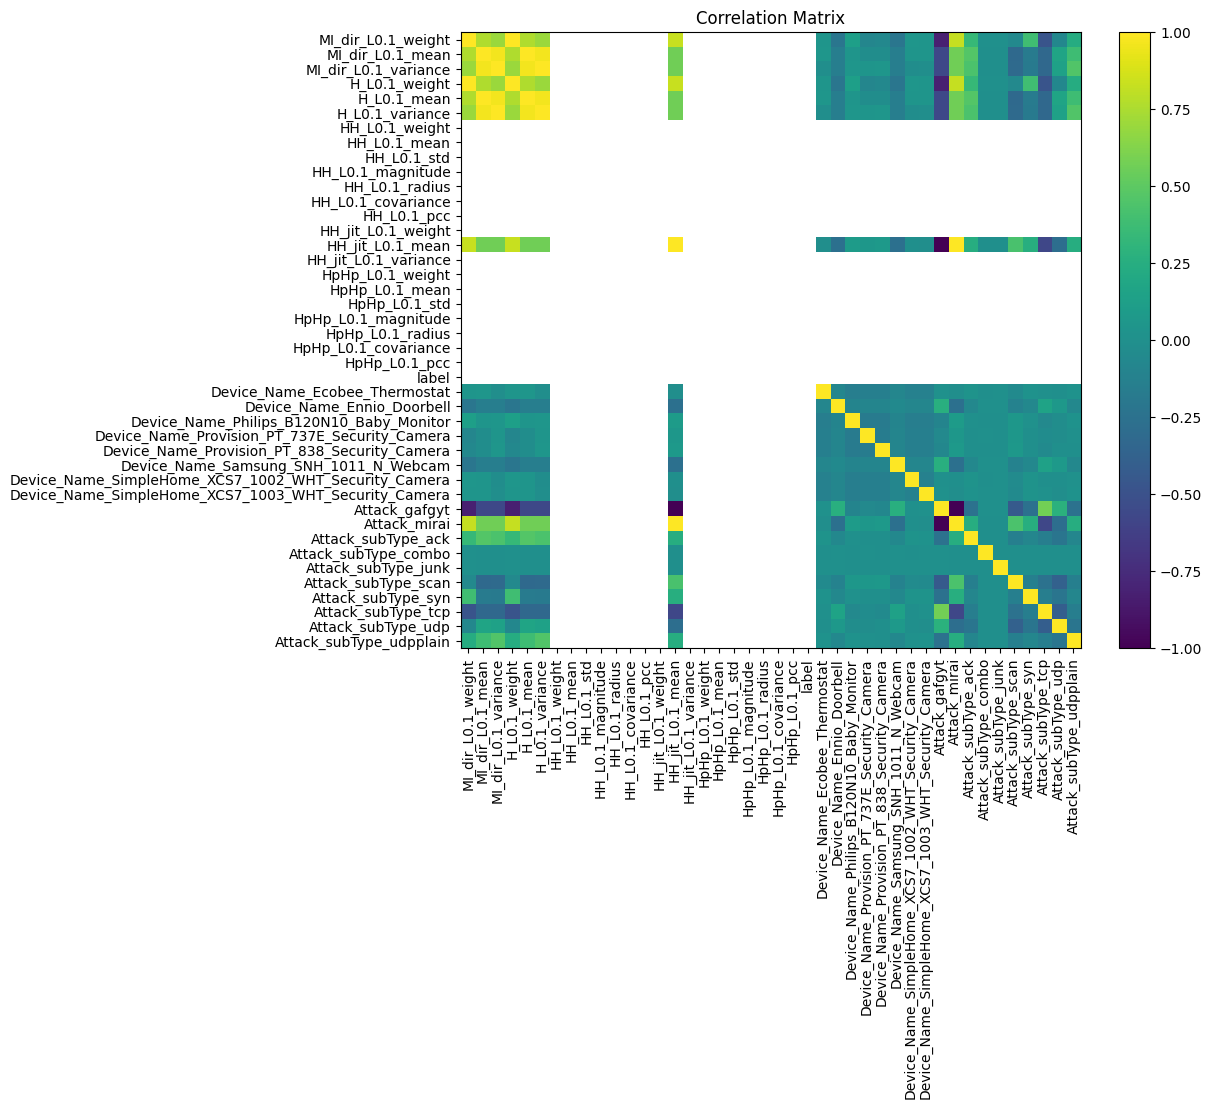

In [19]:
correlation = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(correlation, aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.show()

# 15) Save cleaned dataset

In [21]:
df.to_csv("cleaned_IoT.csv", index=False)

print("\nPreprocessing completed successfully.")
print("Cleaned dataset saved as cleaned_IoT.csv")


Preprocessing completed successfully.
Cleaned dataset saved as cleaned_IoT.csv
